# Workshop 2 - Machine Learning
## **Problema: Predicción de Precios de Vuelos (Regresión)**
### **Integrantes:**

1. Jacobo Pava Quintero

2. Alexander Vargas

3. Cristian Cabarcas López

4. Samuel Herrera Galvis


**Conexión con Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## **ROL 1: DATOS Y PREPROCESAMIENTO**
---
### Fase 1 — EDA, limpieza y preprocesamiento


**Puntos 1, 2 y 3:** Documentación, variable objetivo, diccionarios y .describe().

**Punto 1. Problema de negocio y Variable Objetivo:**
*   **Problema de negocio:** El objetivo es predecir el precio de los tiquetes aéreos en la India utilizando la plataforma "Ease My Trip". Esto es valioso para los pasajeros, ya que les permite saber con antelación cómo variables como la aerolínea, la anticipación de compra o la clase (económica/ejecutiva) afectan el costo del vuelo, permitiéndoles tomar decisiones de compra más inteligentes.
*   **Variable objetivo (Target):** La columna `price` (precio del billete). Dado que es un valor numérico continuo, estamos abordando un problema de regresión.

**Punto 2. Diccionario de datos:**
*   `airline` (Categórica): Nombre de la compañía aérea.
*   `flight` (Categórica): Código de identificación del vuelo.
*   `source_city` (Categórica): Ciudad de origen del vuelo.
*   `departure_time` (Categórica): Franja horaria de salida (ej. Morning, Night).
*   `stops` (Categórica): Número de paradas/escalas del vuelo.
*   `arrival_time` (Categórica): Franja horaria de llegada.
*   `destination_city` (Categórica): Ciudad de destino.
*   `class` (Categórica): Clase del asiento (Economy o Business).
*   `duration` (Numérica): Duración total del viaje en horas.
*   `days_left` (Numérica): Días de anticipación entre la reserva y el viaje.
*   `price` (Numérica / Target): Precio final del billete de avión.


**2.1 Cargar el dataset**

In [2]:
# Importar la librería principal para manejo de datos
import pandas as pd

# 1. Cargar el dataset
ruta_archivo = "/content/drive/MyDrive/ Fundamentos_de_Aprendizaje_Automatico_2026-2/Workshops/Workshop 2/data/data_1_Regresion_Vuelos/Clean_Dataset_Flight Price Prediction.csv"
df_vuelos = pd.read_csv(ruta_archivo)

**2.2 Eliminar la columna 'Unnamed: 0' ya que es solo un índice residual del archivo CSV original**

In [3]:
# Eliminar la columna 'Unnamed: 0' ya que es solo un índice residual del archivo CSV original
if 'Unnamed: 0' in df_vuelos.columns:
    df_vuelos = df_vuelos.drop(columns=['Unnamed: 0'])

**2.3 Inspección inicial (.shape, .info(), head(), tail())**

In [4]:
# 2. Inspección inicial (.shape, .info(), head(), tail())
print(f"Dimensión del dataset (Filas, Columnas): {df_vuelos.shape}\n")

print("--- Información general del dataset ---")
df_vuelos.info()

print("\n--- Primeras 5 filas (head) ---")
display(df_vuelos.head())

print("\n--- Últimas 5 filas (tail) ---")
display(df_vuelos.tail())

Dimensión del dataset (Filas, Columnas): (300153, 11)

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB

--- Primeras 5 filas (head) ---


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955



--- Últimas 5 filas (tail) ---


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


**Punto 3. Estadísticas descriptivas de las variables numéricas**

In [5]:
# 3. Estadísticas descriptivas de las variables numéricas
print("\n--- Estadísticas descriptivas (.describe) ---")
display(df_vuelos.describe())


--- Estadísticas descriptivas (.describe) ---


,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


**Interpretación de estadísticos en términos del problema (Punto 3):**

1.  **Interpretación del Precio (`price`):** El precio promedio de un tiquete es de ~20,889 rupias. Sin embargo, hay una desviación estándar muy alta (22,697) y vemos que el 75% de los tiquetes cuestan 42,521 o menos, pero el valor máximo se dispara a 123,071. Esto nos indica que los precios están muy sesgados hacia arriba, muy probablemente por la diferencia enorme de costos entre la clase económica y la clase ejecutiva (Business).
2.  **Interpretación de la Anticipación (`days_left`):** En promedio, los usuarios compran con 26 días de anticipación. El valor mínimo es 1 día (compras de último minuto) y el máximo es 49 días. Esto confirma el alcance del estudio de recopilación de datos, que fue de poco menos de dos meses de ventana de reserva.
3.  **Interpretación de la Duración (`duration`):** Los vuelos tienen una duración promedio de 12.2 horas. Nos llama la atención que el vuelo más rápido tarda menos de 1 hora (0.83 horas), mientras que el viaje más largo toma casi 50 horas (49.83 horas), lo que claramente indica vuelos con largas escalas (múltiples paradas).

**Puntos 4, 5 y 6:** Nulos, duplicados e inconsistencias (Justificar estrategias).


In [6]:
# --- Punto 4: Identificación de Nulos ---
nulos_por_columna = df_vuelos.isnull().sum()
print("Valores Nulos por columna:\n", nulos_por_columna)

# --- Punto 5: Identificación y eliminación de duplicados ---
duplicados = df_vuelos.duplicated().sum()
print(f"\nFilas duplicadas exactas encontradas: {duplicados}")

# --- Punto 6: Revisión de inconsistencias en categorías ---
print("\nRevisión de categorías únicas en variables tipo texto:")
categoricas = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
for col in categoricas:
    print(f"{col}: {df_vuelos[col].unique()}")

# Nota: Como buena práctica, vamos a estandarizar los nombres de las categorías a minúsculas
# para evitar problemas de formato en el futuro, aunque los datos vienen bien formateados.
for col in categoricas:
    df_vuelos[col] = df_vuelos[col].str.lower()

Valores Nulos por columna:
 airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Filas duplicadas exactas encontradas: 0

Revisión de categorías únicas en variables tipo texto:
airline: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
source_city: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
departure_time: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
stops: ['zero' 'one' 'two_or_more']
arrival_time: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
destination_city: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
class: ['Economy' 'Business']


**Transformación para convertir todos los strings de las variables categóricas a minúsculas**

In [11]:
for col in categoricas:
    print(f"{col}: {df_vuelos[col].unique()}")

airline: ['spicejet' 'airasia' 'vistara' 'go_first' 'indigo' 'air_india']
source_city: ['delhi' 'mumbai' 'bangalore' 'kolkata' 'hyderabad' 'chennai']
departure_time: ['evening' 'early_morning' 'morning' 'afternoon' 'night' 'late_night']
stops: ['zero' 'one' 'two_or_more']
arrival_time: ['night' 'morning' 'early_morning' 'afternoon' 'evening' 'late_night']
destination_city: ['mumbai' 'bangalore' 'kolkata' 'hyderabad' 'chennai' 'delhi']
class: ['economy' 'business']


**Justificación de limpieza (Puntos 4, 5 y 6):**

*   **Valores Nulos (Punto 4):** Al verificar el dataset, comprobamos que no existen valores nulos en ninguna de las columnas. Dado que el porcentaje de datos faltantes es del 0%, no es necesario proponer ninguna estrategia de imputación (ni media, moda o K-NN) ni eliminar filas. El conjunto está completo.
*   **Datos Duplicados (Punto 5):** Se realizó la verificación de filas duplicadas exactas en el dataset (es decir, registros idénticos en las 11 características simultáneamente). El resultado arrojó 0 filas duplicadas, por lo que no se eliminó ningún registro.
*   **Inconsistencias de Formato (Punto 6):** Al revisar los valores únicos de las variables categóricas, no se encontraron errores tipográficos graves ni categorías duplicadas por espacios o mayúsculas (por ejemplo, no hay 'Economy' y 'economy' mezclados). Sin embargo, como medida preventiva y estándar de calidad de datos, se aplicó una transformación para convertir todos los strings de las variables categóricas a minúsculas.

**Puntos 7 y 8:** Outliers (IQR) y Gráficas de EDA (Barras, Pie, Hist, Scatter, Boxplot).


Outliers en 'price': 123 (Valores mayores a 99128.00)
Outliers en 'duration': 2110 (Valores mayores a 30.18 horas)


/tmp/ipykernel_1836/2679299721.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,0], x='airline', y='price', data=df_vuelos, palette='viridis')
/tmp/ipykernel_1836/2679299721.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2,0], x='class', y='price', data=df_vuelos, palette='Set2')


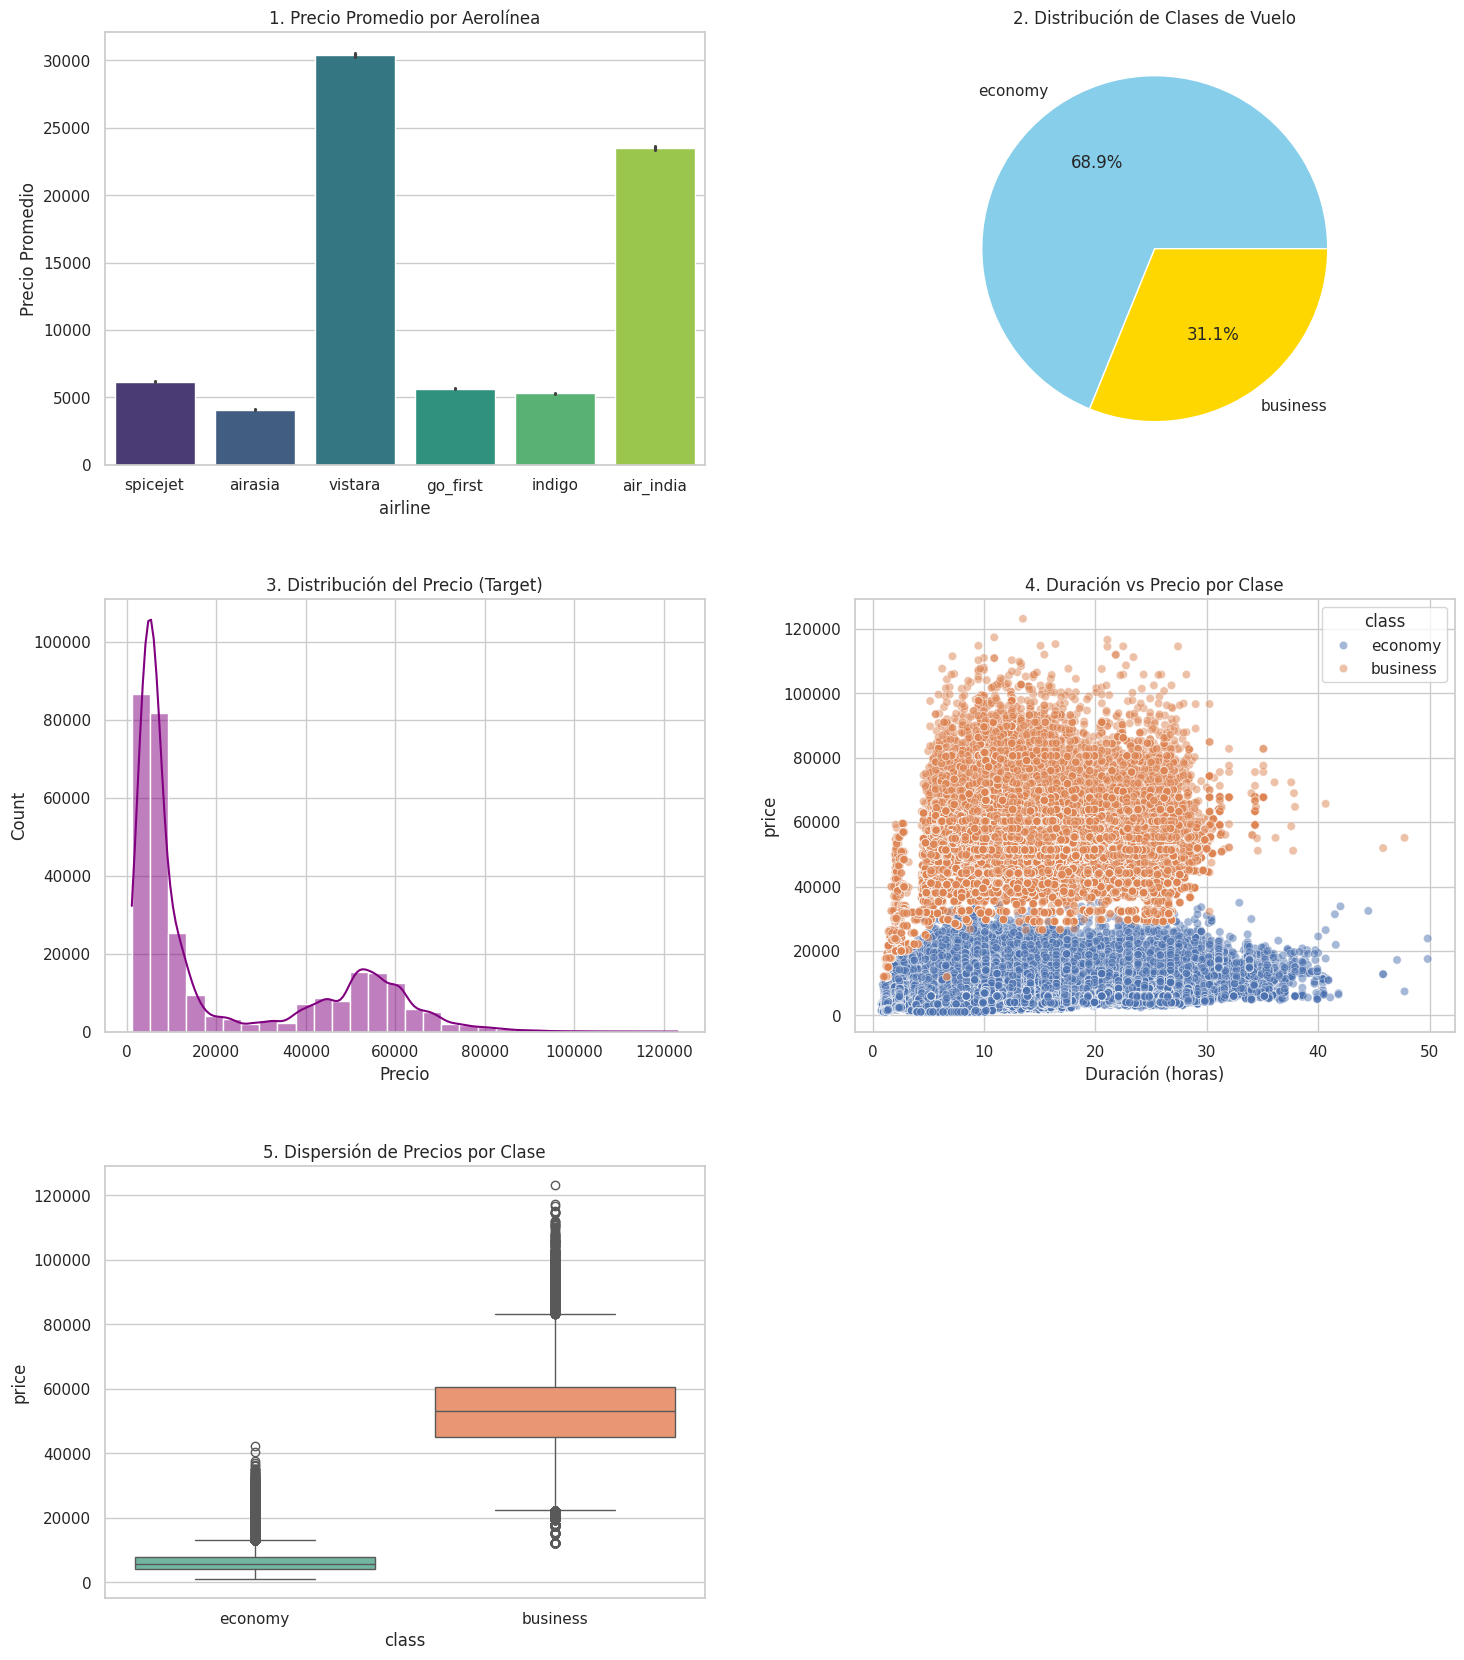

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Punto 7: Detección de Outliers (Criterio IQR) ---
def calcular_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return len(outliers), limite_superior

outliers_precio, lim_sup_precio = calcular_outliers_iqr(df_vuelos, 'price')
outliers_duracion, lim_sup_duracion = calcular_outliers_iqr(df_vuelos, 'duration')

print(f"Outliers en 'price': {outliers_precio} (Valores mayores a {lim_sup_precio:.2f})")
print(f"Outliers en 'duration': {outliers_duracion} (Valores mayores a {lim_sup_duracion:.2f} horas)")

# --- Punto 8: Visualizaciones EDA ---
# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.tight_layout(pad=6.0)

# 1. Gráfico de Barras: Precio promedio por aerolínea
sns.barplot(ax=axes[0,0], x='airline', y='price', data=df_vuelos, palette='viridis')
axes[0,0].set_title('1. Precio Promedio por Aerolínea')
axes[0,0].set_ylabel('Precio Promedio')

# 2. Gráfico de Pie: Proporción de clases (Economy vs Business)
conteo_clases = df_vuelos['class'].value_counts()
axes[0,1].pie(conteo_clases, labels=conteo_clases.index, autopct='%1.1f%%', colors=['skyblue', 'gold'])
axes[0,1].set_title('2. Distribución de Clases de Vuelo')

# 3. Histograma: Distribución de precios
sns.histplot(ax=axes[1,0], data=df_vuelos, x='price', bins=30, kde=True, color='purple')
axes[1,0].set_title('3. Distribución del Precio (Target)')
axes[1,0].set_xlabel('Precio')

# 4. Scatter Plot: Relación entre Duración y Precio
sns.scatterplot(ax=axes[1,1], x='duration', y='price', hue='class', data=df_vuelos, alpha=0.5)
axes[1,1].set_title('4. Duración vs Precio por Clase')
axes[1,1].set_xlabel('Duración (horas)')

# 5. Boxplot: Distribución de Precios según la Clase
sns.boxplot(ax=axes[2,0], x='class', y='price', data=df_vuelos, palette='Set2')
axes[2,0].set_title('5. Dispersión de Precios por Clase')

# Ocultamos el último gráfico (vacío)
axes[2,1].axis('off')

plt.show()

**Punto 7: Tratamiento de Outliers**
*   **Análisis:** Utilizando el rango intercuartílico (IQR), se detectaron **123 outliers en el precio** (tiquetes superiores a ~99,128 rupias) y **2,110 outliers en la duración** (vuelos de más de ~30.18 horas).
*   **Decisión justificada:** No se eliminarán. En el contexto de negocio de las aerolíneas, un vuelo de 100,000 rupias no es un error de digitación, sino un tiquete real de Clase Ejecutiva (Business) comprado probablemente a última hora. De igual forma, las duraciones de más de 30 horas corresponden a vuelos con múltiples escalas (two_or_more stops). Eliminar estos datos le quitaría al modelo la capacidad de predecir estos escenarios reales y altamente rentables para la plataforma.

**Punto 8: Interpretación de Gráficas y Recomendaciones de Negocio**
1.  **Barras (Precio vs Aerolínea):** Vistara y Air India tienen los precios promedio significativamente más altos.

**Recomendación:** La plataforma debería ofrecer campañas de fidelización específicas para los usuarios de estas dos aerolíneas, ya que dejan el mayor margen de ingresos.

2.  **Pie (Clases de Vuelo):** El 68.9% de los tiquetes son económicos y el 31.1% son ejecutivos.

**Recomendación:** Aunque la clase ejecutiva es minoría, representa la mayor inyección de capital. El marketing debe estar balanceado: volumen para la clase económica y exclusividad para la ejecutiva.

3.  **Histograma (Distribución de Precios):** Existe una distribución "bimodal" (dos picos). Un pico enorme en precios bajos (Economy) y una "joroba" extendida en precios altos (Business).

**Recomendación:** Crear sistemas de filtrado rápido en la plataforma que separen automáticamente las búsquedas por presupuesto, ya que el mercado está claramente dividido en dos tipos de cliente.

4.  **Scatter Plot (Duración vs Precio):** Vemos dos "nubes" de puntos claramente separadas por el color (clase). La duración tiene una relación positiva leve con el precio, pero el diferenciador abismal es la clase.

**Recomendación:** Mostrar a los usuarios de clase ejecutiva vuelos más cortos como primera opción, ya que están pagando un alto precio y valorarán la eficiencia del tiempo.

5.  **Boxplot (Precios por Clase):** Se confirma visualmente que el rango de precios de la clase económica es sumamente estrecho y bajo, mientras que la clase business tiene una caja muy amplia y alta. No se superponen en absoluto.

**Puntos 9 y 10:** Codificación de categóricas y Escalamiento de numéricas (Justificar técnica elegida).


In [13]:
# --- Punto 9: Estrategia de Encoding para variables categóricas ---

# Variables Nominales (Sin un orden natural de jerarquía) -> Usaremos One-Hot Encoding
cols_one_hot = ['airline', 'source_city', 'destination_city']

# Variables Ordinales (Tienen un orden o jerarquía implícita) -> Usaremos Ordinal Encoding
cols_ordinales = ['stops', 'class', 'departure_time', 'arrival_time']

# Definimos el orden explícito para las variables ordinales para que el modelo lo entienda
orden_stops = ['zero', 'one', 'two_or_more']
orden_class = ['economy', 'business']
orden_tiempo = ['early_morning', 'morning', 'afternoon', 'evening', 'night', 'late_night']

# --- Punto 10: Estrategia de Escalamiento para variables numéricas ---
cols_numericas = ['duration', 'days_left']

**Justificación de Codificación (Encoding) - Punto 9:**
Para codificar las variables categóricas se tomó la siguiente decisión basándonos en la naturaleza de cada una y en los algoritmos a utilizar (como KNN y Regresión Lineal, que son sensibles a los números asignados):

1.  **One-Hot Encoding (`airline`, `source_city`, `destination_city`):** Estas variables son *nominales*; es decir, no existe un orden jerárquico natural entre las ciudades (Delhi no es "mayor" que Mumbai) ni entre las aerolíneas. Si usáramos Ordinal Encoding, los modelos lineales o basados en distancia (como KNN) asumirían erróneamente que una aerolínea codificada con "5" vale más que una con "1". Por ello, One-Hot Encoding es la técnica correcta.
2.  **Ordinal Encoding (`stops`, `class`, `departure_time`, `arrival_time`):** Estas variables sí tienen un orden lógico y secuencial.
    *   `stops`: 'zero' < 'one' < 'two_or_more'. A mayor número de paradas, mayor fatiga o tiempo.
    *   `class`: 'economy' < 'business'. Existe una jerarquía clara de lujo y precio.
    *   `departure/arrival time`: Tienen una secuencia cronológica natural durante el día (madrugada, mañana, tarde, noche).
    *   Codificarlas ordinalmente mantiene esta información jerárquica valiosa para modelos como los Árboles de Decisión sin inflar artificialmente la cantidad de columnas del dataset.

**Aclaración sobre la columna flight:** Esta característica no fue incluida en ninguna técnica de codificación debido a su altísima cardinalidad (1,561 valores únicos) y su naturaleza de identificador. Codificarla generaría ruido y problemas de dimensionalidad, por lo que será eliminada del dataset antes de construir el Pipeline.

**Justificación de Escalamiento (Scaling) - Punto 10:**
Los algoritmos que se entrenarán en la Fase 3 incluyen *KNN* y *Regresión Lineal*, los cuales son extremadamente sensibles a la escala de las variables (si 'duration' va de 1 a 50 y 'days_left' va de 1 a 300, el modelo le dará un peso desproporcionado a la de mayor magnitud).

*   **Técnica elegida:** **RobustScaler**.
*   **Justificación:** Como descubrimos en el *Punto 7*, la variable `duration` tiene más de 2,100 valores atípicos (outliers reales de vuelos con muchas escalas) que decidimos no eliminar. Si usáramos *MinMaxScaler* o *StandardScaler*, estos valores extremos aplastarían la distribución de los datos normales, distorsionando el modelo. RobustScaler utiliza la mediana y el rango intercuartílico (IQR) en lugar de la media y la varianza, por lo que es la técnica ideal para escalar nuestras variables numéricas sin que los outliers arruinen el proceso.

### Fase 2 — División de datos y Pipelines


**Puntos 11, 12 y 13:** División Train/Val/Test (ej. 70/15/15), Pipeline con ColumnTransformer y verificación de no Data Leakage.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# --- Preparación Previa ---
# 1. Eliminamos la columna 'flight' por alta cardinalidad
df_vuelos_clean = df_vuelos.drop(columns=['flight']).copy()

# 2. Separamos las características (X) de la variable objetivo (y)
X = df_vuelos_clean.drop(columns=['price'])
y = df_vuelos_clean['price']

# --- Punto 11: División Train / Validation / Test (70/15/15) ---
# Primero, sacamos un 15% para TEST. El 85% restante queda en 'temp'.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Segundo, de ese 85% (temp), sacamos la proporción exacta para que Validation sea el 15% del TOTAL.
# (0.15 / 0.85) = 0.1764. Al sacar el 17.64% de temp, obtenemos exactamente el 15% del dataset original.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42)

print(f"Tamaño Total: {len(df_vuelos_clean)} filas")
print(f"Set de Entrenamiento (Train): {len(X_train)} filas")
print(f"Set de Validación (Val): {len(X_val)} filas")
print(f"Set de Prueba (Test): {len(X_test)} filas")


# --- Punto 12: Construcción del ColumnTransformer y Pipeline ---
# Reutilizamos las listas del Punto 9 y 10

# Transformador 1: Para numéricas (RobustScaler)
num_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

# Transformador 2: Para categóricas nominales (OneHotEncoder)
# drop='first' ayuda a evitar la multicolinealidad perfecta en modelos lineales
cat_nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Transformador 3: Para categóricas ordinales (OrdinalEncoder)
cat_ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[orden_stops, orden_class, orden_tiempo, orden_tiempo], handle_unknown='use_encoded_value', unknown_value=-1))
])

# Integramos todo en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, cols_numericas),
        ('cat_nom', cat_nominal_transformer, cols_one_hot),
        ('cat_ord', cat_ordinal_transformer, cols_ordinales)
    ],
    remainder='passthrough' # Por si acaso se nos queda alguna columna, que la deje pasar intacta
)

# --- Punto 13: Aplicación del Pipeline EVITANDO Data Leakage ---
# IMPORTANTE: El .fit() solo aprende del X_train.
X_train_processed = preprocessor.fit_transform(X_train)

# A Validación y Test solo se les aplica .transform(), usando las reglas aprendidas de Train.
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("\n¡Pipeline ejecutado correctamente sin fuga de datos!")
print(f"Número de características originales: {X.shape[1]}")
print(f"Número de características después del Pipeline: {X_train_processed.shape[1]}")

Tamaño Total: 300153 filas
Set de Entrenamiento (Train): 210107 filas
Set de Validación (Val): 45023 filas
Set de Prueba (Test): 45023 filas

¡Pipeline ejecutado correctamente sin fuga de datos!
Número de características originales: 9
Número de características después del Pipeline: 21


**Punto 11: Propósito de la División Train / Validation / Test**

Se realizó una división del 70% para Entrenamiento, 15% para Validación y 15% para Test.
*   **Train (70%):** Es el conjunto con el que el algoritmo de Machine Learning aprende a encontrar los patrones que relacionan las características con el precio del vuelo.
*   **Validation (15%):** Es un conjunto intermedio que el modelo no ha visto durante el entrenamiento. Sirve para comparar los 5 algoritmos, afinar los hiperparámetros y detectar si el modelo tiene Overfitting (memorizó los datos de train pero le va mal aquí).
*   **Por qué no basta solo con Train/Test:** Si solo usamos Train y Test, y usamos el Test para afinar hiperparámetros y elegir el mejor modelo, el modelo terminaría "aprendiéndose" los patrones del Test de forma indirecta. El conjunto de Validación asume ese rol de ajuste, permitiendo que el Test quede 100% "virgen" y aislado para simular datos nuevos del mundo real en la evaluación final.

**Punto 12: Justificación del Pipeline**

Se construyó un `ColumnTransformer` que orquesta los tres tipos de transformaciones definidos en la Fase 1 (`RobustScaler` para numéricas, `OneHotEncoder` para categóricas nominales y `OrdinalEncoder` para categóricas con jerarquía). Al no existir datos nulos (Punto 4), se omitieron pasos innecesarios de imputación (como `SimpleImputer`) para hacer el Pipeline más eficiente.

**Punto 13: Verificación de ausencia de Data Leakage (Fuga de Datos)**

El diseño de este código garantiza estrictamente que no existe fuga de datos. La "fuga" ocurre cuando información de Validación o Test se cuela en el entrenamiento, dándole al modelo una ventaja injusta. Para evitarlo:
1.  Se realizó el `train_test_split` **antes** de aplicar cualquier transformación.
2.  El Pipeline ejecutó el método `.fit_transform()` **exclusivamente sobre `X_train`**. Esto significa que los valores máximos, mínimos y el IQR del escalador, así como las categorías del codificador, se calcularon únicamente viendo el 70% de los datos.
3.  Sobre los conjuntos `X_val` y `X_test` se aplicó únicamente el método `.transform()`. Así, estos conjuntos fueron escalados y codificados utilizando las "reglas matemáticas" que el Pipeline memorizó de Train, manteniéndolos completamente asilados y simulando datos del mundo real.

---
## **ROL 2: MODELOS Y EVALUACIÓN**
---



### Fase 3 — Modelado: Regresión
**Puntos 14 y 15:** Entrenamiento (Lineal, KNN, Decision Tree, Random Forest, Gradient Boosting) y predicción en Validación.


In [ ]:
# Entrenamiento de los 5 modelos de Regresión


### Fase 5 — Métricas (Train vs Validación)
**Puntos 18, 20 y 21:** MAE, MSE, R². Tabla comparativa, detección de Overfitting/Underfitting y selección justificada del mejor modelo.


In [ ]:
# Cálculo de métricas y tabla comparativa


### Fase 6 — Evaluación final en el conjunto de Test
**Puntos 22 y 23:** Evaluar TODOS los modelos en Test. Tabla final comparando Test vs Validación.


In [ ]:
# Evaluación en conjunto de prueba (Test)


### Fase 7 — Cross Validation
**Puntos 24 al 27:** Explicación teórica de K-Fold. Implementación en el *mejor modelo* y comparación contra validación original.


In [ ]:
# Implementación y análisis de K-Fold Cross Validation


---
## **TRABAJO EN EQUIPO**
---
### Fase 8 — Conclusiones
**Punto 28:** Conclusiones conjuntas. Limitaciones, algoritmos y subplot con mejores gráficas.


In [ ]:
# Subplot de gráficas importantes y texto de conclusiones finales
